<a href="https://colab.research.google.com/github/tirthas970-cmyk/AeroTrack-Prime/blob/main/Baseline_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sunpy[all] drms
!pip install huggingface_hub
!pip install webdataset -q

In [ ]:
from google.colab import drive, userdata

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import io
import os
import tarfile
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from huggingface_hub import snapshot_download
from google.colab import userdata

# --- 1. Download data shards (from original cell 4BJ3gze5gcTq) ---
print("Initiating filtered download: Fetching ONLY v2 .tar shards...")
try:
    local_data_path = snapshot_download(
        repo_id="X-FlareNet/solar-flare-magnetogram-shards",
        repo_type="dataset",
        token=userdata.get("hf_token"),
        local_dir="/content/local_solar_shards",
        allow_patterns=["*v2*.tar"]
    )
    print(f"\n[SUCCESS] v2 shards downloaded locally at: {local_data_path}")
    print("Verifying downloaded files:")
    os.system(f"ls -lR {local_data_path}") # Explicitly list files to confirm
    print("Checking remaining disk space:")
    os.system("df -h /content")
except Exception as e:
    print(f"\n[ERROR] Filtered download failed: {e}")

# --- 2. Load Active Region splits (from original cell -C9pepmaggGt) ---
with open("/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/train_ars.txt", "r") as f:
    train_set = set(int(line.strip()) for line in f if line.strip())

with open("/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/val_ars.txt", "r") as f:
    val_set = set(int(line.strip()) for line in f if line.strip())

with open("/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/test_ars.txt", "r") as f:
    test_set = set(int(line.strip()) for line in f if line.strip())

print(f"[SUCCESS] Loaded {len(train_set)} training regions and {len(val_set)} validation regions back into RAM!")

# --- 3. Define Dataset Class and DataLoaders (from original cell mejRLqmNgngi) ---
class FastLocalSolarDataset(Dataset):
    def __init__(self, local_dir, allowed_ar_set):
        # Diagnostic: List contents of the local_dir
        print(f"[DEBUG] Listing contents of {local_dir}:")
        os.system(f"ls -R {local_dir}")
        print("-------------------------------------")

        # Changed to recursive glob to find .tar files in subdirectories as well
        self.tar_files = sorted(glob.glob(os.path.join(local_dir, "**", "*.tar"), recursive=True))
        self.allowed_ar_set = allowed_ar_set
        self.samples = []

        print(f"Indexing local files... Parsing headers from {len(self.tar_files)} shards.")

        if not self.tar_files: # Added a check for empty tar_files
            print(f"[WARNING] No .tar files found in {local_dir} or its subdirectories.")
            print("Please ensure the data download in the previous step was successful and the files are in the expected location.")
            return # Exit early if no tar files are found to prevent further errors

        for tar_path in self.tar_files:
            with tarfile.open(tar_path, "r") as tar:
                for member in tar.getmembers():
                    if member.isfile():
                        filename = member.name
                        base_key, ext = filename.rsplit('.', 1)

                        try:
                            first_part = base_key.split("_")[0]
                            ar_num = int(first_part.replace("AR", ""))
                            # Filter based on your Active Region splits
                            if ar_num in self.allowed_ar_set:
                                self.samples.append((tar_path, member.name))
                        except Exception:
                            continue
        print(f"Index complete! Found {len(self.samples)} valid split-bound frames.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        tar_path, member_name = self.samples[idx]
        base_key, ext = member_name.rsplit('.', 1)

        with tarfile.open(tar_path, "r") as tar:
            npy_member = tar.getmember(f"{base_key}.npy")
            txt_member = tar.getmember(f"{base_key}.txt")

            img_bytes = tar.extractfile(npy_member).read()
            lbl_bytes = tar.extractfile(txt_member).read()

        img = np.load(io.BytesIO(img_bytes)).astype(np.float32)
        solar_mask = (img != 0.0)
        norm_pixels = np.zeros_like(img, dtype=np.float32)
        clipped = np.clip(img[solar_mask], -4000.0, 4000.0)
        norm_pixels[solar_mask] = (clipped + 4000.0) / 8000.0

        img_tensor = torch.tensor(norm_pixels, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(int(lbl_bytes.decode('utf-8').strip()), dtype=torch.long)
        tabular_placeholder = torch.zeros(1, dtype=torch.float32)

        return img_tensor, tabular_placeholder, label_tensor


train_dataset = FastLocalSolarDataset("/content/local_solar_shards", train_set)
val_dataset = FastLocalSolarDataset("/content/local_solar_shards", val_set)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)


Initiating filtered download: Fetching ONLY v2 .tar shards...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 339 files:   0%|          | 0/339 [00:00<?, ?it/s]


[SUCCESS] v2 shards downloaded locally at: /content/local_solar_shards
Verifying downloaded files:
Checking remaining disk space:
[SUCCESS] Loaded 716 training regions and 122 validation regions back into RAM!
[DEBUG] Listing contents of /content/local_solar_shards:
-------------------------------------
Indexing local files... Parsing headers from 339 shards.
Index complete! Found 92594 valid split-bound frames.
[DEBUG] Listing contents of /content/local_solar_shards:
-------------------------------------
Indexing local files... Parsing headers from 339 shards.
Index complete! Found 16858 valid split-bound frames.


In [ ]:

#USE GPU FOR THIS AS WELL
from huggingface_hub import snapshot_download
from google.colab import userdata
import os

print("Initiating filtered download: Fetching ONLY v2 .tar shards...")
try:
    local_data_path = snapshot_download(
        repo_id="X-FlareNet/solar-flare-magnetogram-shards",
        repo_type="dataset",
        token=userdata.get("hf_token"),
        local_dir="/content/local_solar_shards",
        allow_patterns=["*v2*.tar"]
    )
    print(f"\n[SUCCESS] v2 shards downloaded locally at: {local_data_path}")
    print("Checking remaining disk space:")
    os.system("df -h /content")
except Exception as e:
    print(f"\n[ERROR] Filtered download failed: {e}")


Initiating filtered download: Fetching ONLY v2 .tar shards...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 339 files:   0%|          | 0/339 [00:00<?, ?it/s]


[SUCCESS] v2 shards downloaded locally at: /content/local_solar_shards
Checking remaining disk space:


In [9]:


with open("/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/train_ars.txt", "r") as f:
    train_set = set(int(line.strip()) for line in f if line.strip())

with open("/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/val_ars.txt", "r") as f:
    val_set = set(int(line.strip()) for line in f if line.strip())

with open("/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/test_ars.txt", "r") as f:
    test_set = set(int(line.strip()) for line in f if line.strip())

print(f"[SUCCESS] Loaded {len(train_set)} training regions and {len(val_set)} validation regions back into RAM!")


[SUCCESS] Loaded 716 training regions and 122 validation regions back into RAM!


In [10]:
import io
import os
import tarfile
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class FastLocalSolarDataset(Dataset):
    def __init__(self, local_dir, allowed_ar_set):
        # Diagnostic: List contents of the local_dir
        print(f"[DEBUG] Listing contents of {local_dir}:")
        os.system(f"ls -R {local_dir}")
        print("-------------------------------------")

        # Changed to recursive glob to find .tar files in subdirectories as well
        self.tar_files = sorted(glob.glob(os.path.join(local_dir, "**", "*.tar"), recursive=True))
        self.allowed_ar_set = allowed_ar_set
        self.samples = []

        print(f"Indexing local files... Parsing headers from {len(self.tar_files)} shards.")

        if not self.tar_files: # Added a check for empty tar_files
            print(f"[WARNING] No .tar files found in {local_dir} or its subdirectories.")
            print("Please ensure the data download in the previous step was successful and the files are in the expected location.")
            return # Exit early if no tar files are found to prevent further errors

        for tar_path in self.tar_files:
            with tarfile.open(tar_path, "r") as tar:
                for member in tar.getmembers():
                    if member.isfile():
                        filename = member.name
                        base_key, ext = filename.rsplit('.', 1)

                        try:
                            first_part = base_key.split("_")[0]
                            ar_num = int(first_part.replace("AR", ""))
                            # Filter based on your Active Region splits
                            if ar_num in self.allowed_ar_set:
                                self.samples.append((tar_path, member.name))
                        except Exception:
                            continue
        print(f"Index complete! Found {len(self.samples)} valid split-bound frames.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        tar_path, member_name = self.samples[idx]
        base_key, ext = member_name.rsplit('.', 1)

        with tarfile.open(tar_path, "r") as tar:
            npy_member = tar.getmember(f"{base_key}.npy")
            txt_member = tar.getmember(f"{base_key}.txt")

            img_bytes = tar.extractfile(npy_member).read()
            lbl_bytes = tar.extractfile(txt_member).read()

        img = np.load(io.BytesIO(img_bytes)).astype(np.float32)
        solar_mask = (img != 0.0)
        norm_pixels = np.zeros_like(img, dtype=np.float32)
        clipped = np.clip(img[solar_mask], -4000.0, 4000.0)
        norm_pixels[solar_mask] = (clipped + 4000.0) / 8000.0

        img_tensor = torch.tensor(norm_pixels, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(int(lbl_bytes.decode('utf-8').strip()), dtype=torch.long)
        tabular_placeholder = torch.zeros(1, dtype=torch.float32)

        return img_tensor, tabular_placeholder, label_tensor


train_dataset = FastLocalSolarDataset("/content/local_solar_shards", train_set)
val_dataset = FastLocalSolarDataset("/content/local_solar_shards", val_set)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

[DEBUG] Listing contents of /content/local_solar_shards:
-------------------------------------
Indexing local files... Parsing headers from 339 shards.
Index complete! Found 92594 valid split-bound frames.
[DEBUG] Listing contents of /content/local_solar_shards:
-------------------------------------
Indexing local files... Parsing headers from 339 shards.
Index complete! Found 16858 valid split-bound frames.


In [ ]:
# weights

#ONCE YOU ARE HEERE -> SWITCH TO GPU

import numpy as np
import torch
from sklearn.utils import class_weight

#Train Split -> Quiet (0): 44472, M-Class (1): 1631, X-Class (2): 194

classes = np.array([0, 1, 2])
counts = np.array([44472, 1631, 194])

y_full = np.repeat(classes, counts)

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_full
)

sqrt_weights = np.sqrt(weights)

class_weight_dict = dict(zip(classes, sqrt_weights))

weights_tensor = torch.tensor(list(class_weight_dict.values()), dtype=torch.float32).cuda()

print(weights_tensor)


tensor([0.5891, 3.0760, 8.9190], device='cuda:0')


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        p_t = torch.exp(-ce_loss)

        focal_weight = (1 - p_t) ** self.gamma
        loss = focal_weight * ce_loss

        if self.alpha is not None:
            self.alpha = self.alpha.to(targets.device)
            batch_weights = self.alpha[targets]
            loss = loss * batch_weights

        return loss.mean()


In [ ]:
#Baseline ResNet-18

import torchvision.models as models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)

model = model.to(device)

criterion = FocalLoss(alpha=weights_tensor, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print(f"ResNet-18 Baseline loaded onto {device} and ready!")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]


ResNet-18 Baseline loaded onto cuda and ready!


In [ ]:
import torch

def train_local_baseline(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    print(f"Starting baseline training loop on local high-speed NVMe data using: {device}...")

    for epoch in range(num_epochs):

        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0
        train_batches = 0

        for batch_idx, (images, _, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Match standard 3-channel input models if needed
            if images.shape[1] == 1:
                images = images.repeat(1, 3, 1, 1)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Tracking metrics
            running_train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            train_batches += 1

            # Print feedback every 50 batches since local data moves insanely fast
            if batch_idx % 50 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}] | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

        epoch_train_loss = running_train_loss / train_batches if train_batches > 0 else 0.0
        train_acc = (correct_train / total_train) * 100 if total_train > 0 else 0.0

        # =====================================================================
        # 2. VALIDATION PHASE
        # =====================================================================
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        val_batches = 0

        with torch.no_grad():
            for images, _, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                if images.shape[1] == 1:
                    images = images.repeat(1, 3, 1, 1)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                val_batches += 1

        epoch_val_loss = running_val_loss / val_batches if val_batches > 0 else 0.0
        val_acc = (correct_val / total_val) * 100 if total_val > 0 else 0.0

        # CLEAN FEEDBACK REPORT MILESTONES (Exactly what you're used to seeing)
        print(f"\n>>> Epoch [{epoch+1}/{num_epochs}] COMPLETE <<<")
        print(f"Loss: {epoch_train_loss:.4f} | Acc: {train_acc:.2f}%")
        print(f"Val_Loss: {epoch_val_loss:.4f} | Val_Acc: {val_acc:.2f}%\n")

        # LOCK IN YOUR PROGRESS TO GOOGLE DRIVE (Safety save point)
        torch.save(model.state_dict(), f"/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/resnet18_local_epoch_{epoch+1}.pth")
        print(f"Checkpoint saved safely for Epoch {epoch+1}!\n")

    print("Training finished!")


In [ ]:
train_local_baseline(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=3
)


Starting baseline training loop on local high-speed NVMe data using: cuda...
Epoch [1/3] | Batch 0/2894 | Loss: 0.2330
Epoch [1/3] | Batch 50/2894 | Loss: 0.1566
Epoch [1/3] | Batch 100/2894 | Loss: 0.1620
Epoch [1/3] | Batch 150/2894 | Loss: 0.3004
Epoch [1/3] | Batch 200/2894 | Loss: 0.0705
Epoch [1/3] | Batch 250/2894 | Loss: 0.0532
Epoch [1/3] | Batch 300/2894 | Loss: 0.2869
Epoch [1/3] | Batch 350/2894 | Loss: 0.0524
Epoch [1/3] | Batch 400/2894 | Loss: 0.0557
Epoch [1/3] | Batch 450/2894 | Loss: 0.0970
Epoch [1/3] | Batch 500/2894 | Loss: 0.0928
Epoch [1/3] | Batch 550/2894 | Loss: 0.1615
Epoch [1/3] | Batch 600/2894 | Loss: 0.1917
Epoch [1/3] | Batch 650/2894 | Loss: 0.0498
Epoch [1/3] | Batch 700/2894 | Loss: 0.0581
Epoch [1/3] | Batch 750/2894 | Loss: 0.0331
Epoch [1/3] | Batch 800/2894 | Loss: 0.0534
Epoch [1/3] | Batch 850/2894 | Loss: 0.0383
Epoch [1/3] | Batch 900/2894 | Loss: 0.1612
Epoch [1/3] | Batch 950/2894 | Loss: 0.0890
Epoch [1/3] | Batch 1000/2894 | Loss: 0.0893
E

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# Define the model architecture again, exactly as it was during training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features_loaded = loaded_model.fc.in_features
loaded_model.fc = nn.Linear(num_features_loaded, 3)

# Specify the path to your saved state dictionary
# Using the model saved after the last epoch (epoch 3)
model_path = "/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/resnet18_local_epoch_3.pth"

# Load the state dictionary
loaded_model.load_state_dict(torch.load(model_path, map_location=device))

# Move the model to the appropriate device
loaded_model = loaded_model.to(device)

# Set the model to evaluation mode (important for inference)
loaded_model.eval()

print(f"Model loaded successfully from {model_path} onto {device} and set to evaluation mode.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 102MB/s]


Model loaded successfully from /content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/resnet18_local_epoch_3.pth onto cpu and set to evaluation mode.


Making predictions on the validation set...


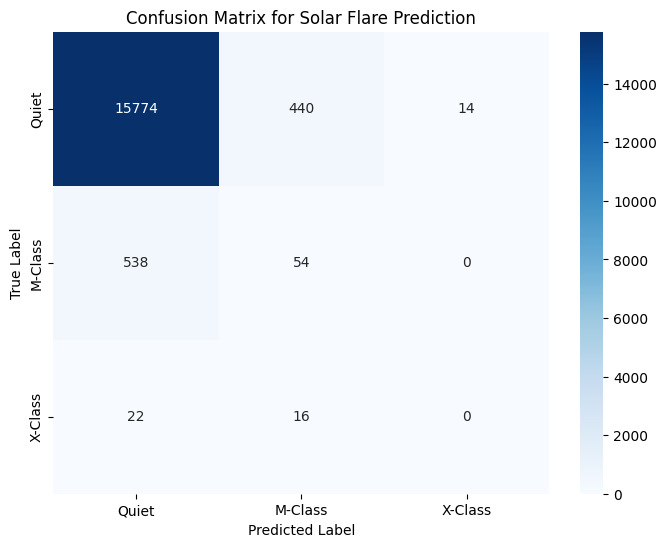

Confusion Matrix calculation and plotting complete.


In [11]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the model is on the correct device and in evaluation mode
loaded_model.to(device)
loaded_model.eval()

all_preds = []
all_labels = []

print("Making predictions on the validation set...")
with torch.no_grad():
    for images, _, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        # Ensure 3-channel input for ResNet-18 if the dataset provides 1-channel
        if images.shape[1] == 1:
            images = images.repeat(1, 3, 1, 1)

        outputs = loaded_model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Define class names (assuming 0: Quiet, 1: M-Class, 2: X-Class based on your weights calculation)
class_names = ['Quiet', 'M-Class', 'X-Class']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Solar Flare Prediction')
plt.show()

print("Confusion Matrix calculation and plotting complete.")

In [1]:
import numpy as np

cm = np.array([
    [15774, 440, 14],   # Actual Quiet
    [538,   54,  0],    # Actual M
    [22,    16,  0]     # Actual X
])
# Original 3-class confusion matrix
#              Pred: Quiet  M      X
# Actual Quiet
# Actual M
# Actual X

# Collapse M and X into one "Flare" class
TN = cm[0, 0]
FP = cm[0, 1] + cm[0, 2]
FN = cm[1, 0] + cm[2, 0]
TP = cm[1, 1] + cm[1, 2] + cm[2, 1] + cm[2, 2]

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

# F1
f1 = (2 * TP) / (2 * TP + FP + FN)

# TSS
tss = (TP / (TP + FN)) - (FP / (FP + TN))

# HSS
hss = (2 * (TP * TN - FP * FN)) / (
    (TP + FN) * (FN + TN) +
    (TP + FP) * (FP + TN)
)

print("F1:", f1)
print("TSS:", tss)
print("HSS:", hss)

TN: 15774
FP: 454
FN: 560
TP: 70
F1: 0.12131715771230503
TSS: 0.08313477391613945
HSS: 0.09044853508788919
